# How Age and Reaction Time Influence Sensorimotor Adaptation


##Background
Sensorimotor adaptation is the process by which individuals adjust their movements in response to altered sensory feedback, allowing for flexible, goal-directed behavior. In this project, adaptation is studied using a visuomotor rotation task, in which the cursor is rotated relative to hand movement, requiring participants to adjust their movements over time.

Early childhood and adolescence represent a critical period of growth, during which the body, brain, and
behavior change at a remarkable pace. During this period, neural networks are especially adaptable,
allowing children to acquire new motor, sensory, and cognitive skills with remarkable speed (Knudsen,
2004, White et al., 2013, Zeanah et al., 2011). Motor development unfolds through the continuous
interaction between the child and their environment, and every new movement provides experience that
shapes future action (Adolph & Franchak, 2017). Understanding how the changes unfold, particularly in
motor control, is crucial for identifying typical developmental trajectories and for studying how adaptation
emerges across our childhood.

Research examining motor adaptation in children has produced mixed results. While children can adapt to perturbations at a young age, efficiency, accuracy, and retention generally improve with age (Contreras-Vidal et al., 2005; Konczak et al., 2003). Differences across studies may reflect variation in methods or underlying learning processes.

 This project uses data from *Large-scale citizen science reveals predictors of sensorimotor adaptation* (Tsay et al., 2024). Participants completed a web-based visuomotor rotation task in which they made reaching movements to move a cursor towards a visual target on the screen (Figure 1). The cursor's trajectory was systematically rotated away from their actual hand movement, forcing them to gradually adjust their movement to account for the error. Over repeated trials, researchers measured how well and how quickly participants adapted to this error, along with collecting basic demographic information through a survey. Adaptation is measured through changes in hand angle, along with performance measures such as movement and reaction time.

 This project investigates how motor adaptation differs between children and young adults, and whether these differences are related to performance measures or behavioral factors.

###Figure 1: Schematic of the Sensorimotor Task

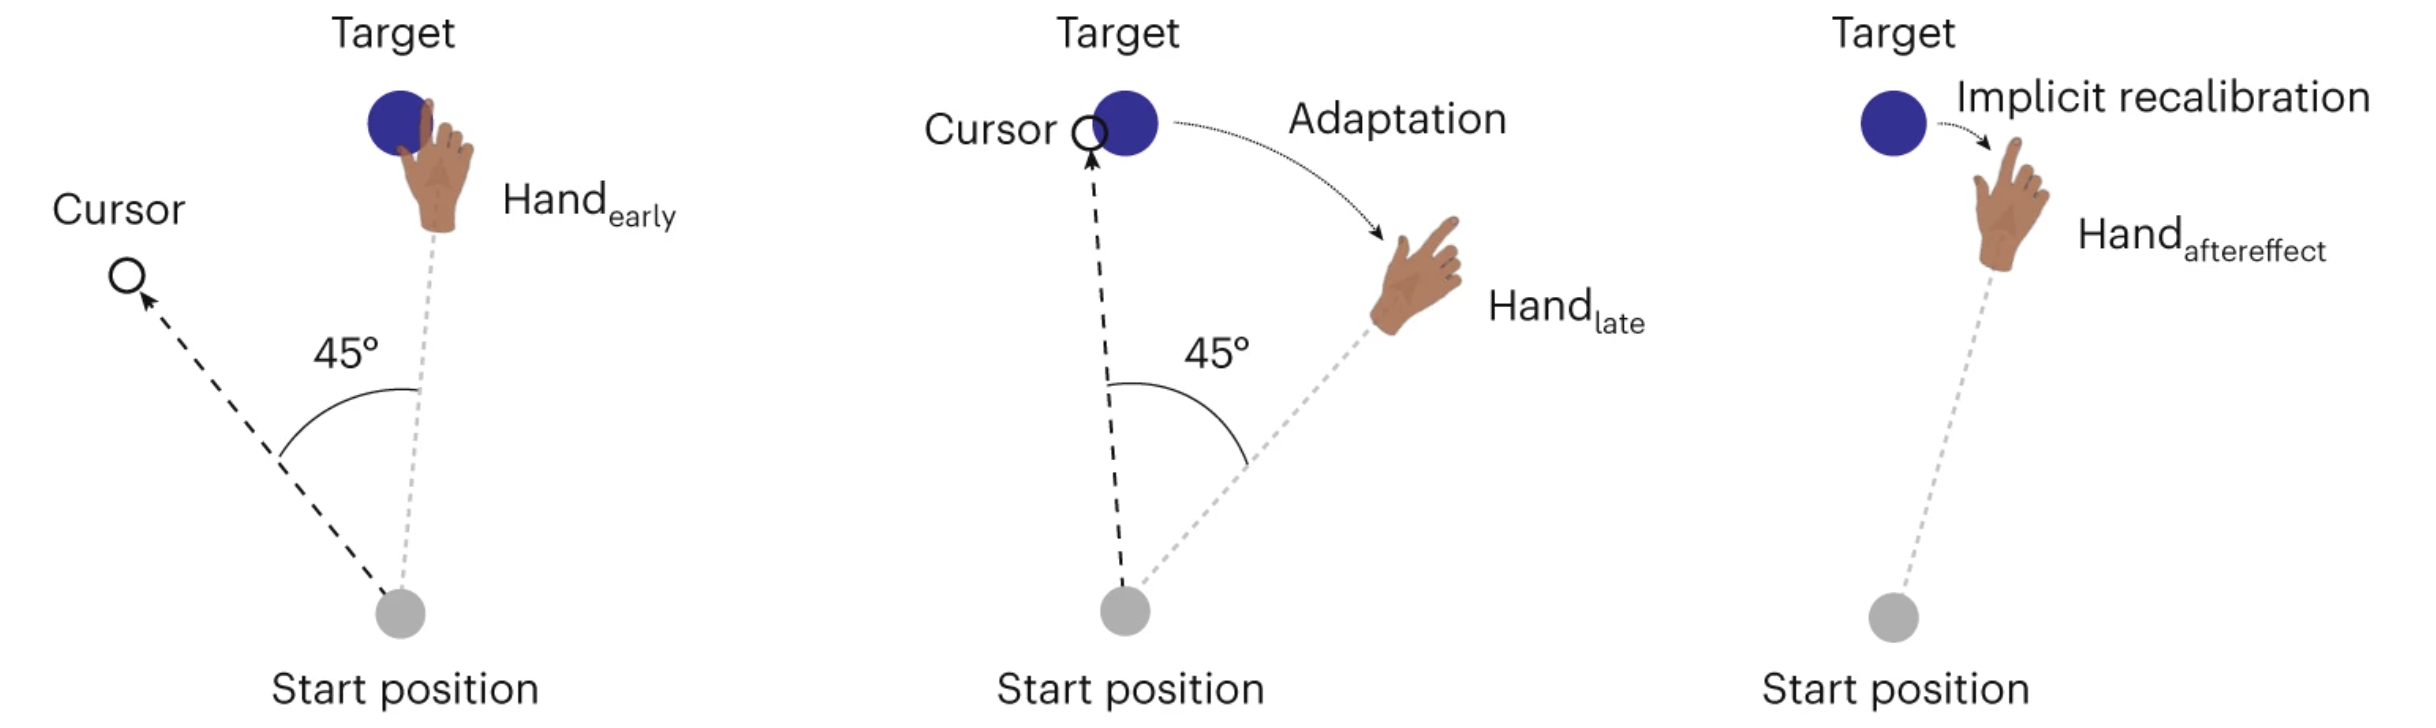

#Variables

###Dataset Structure

The raw dataset is trial-level, meaning that each row corresponds to one trial from one participant. Each participant contributes multiple trials across baseline, adaptation, and aftereffect phases.

The analysis was restricted to participants classified as children (<18 years) and young adults (18-30 years). After filtering, the dataset included:

*   1360 participants
*   4080 total participant-stage observations

For modeling purposes, trial-level data was aggregated to the participant level, resulting in one observation per participant per stage.



**Participant-Level Variables:**

*   `Subject.ID`: Unique participant identifier
*   `Age`: Years reported by participant


**Trial-Level Task Variables:**

*   `TN`: Trial number within the experiment
*   `Block`: Experimental block corresponding to the task phase
*   `ST`: Search time, defined as the time required to return the cursor to the starting position
*   `RT`: Reaction time, defined as the time it takes to initiate movement
*   `MT`: Movement time, defined as the time it takes to reach the target from movement initiation
*   `ri`: Size of rotation
*   `HandFlip`: Hand angle used as a measure of motor adaptation, where larger values indicate greater compensation for the imposed rotation


**Derived Variables**


*   `Stage`: Task stage, defined based on experimental block and trial position
    *   Baseline: Trials with veridical feedback
    *   Early Adaptation: First trials during the rotation phase
    *   Late Adaptation: Last trials during rotation phase
    *   Aftereffect: No-feedback trials following adaptation

*   `Group`: Age group

    *   Child: Age < 18
    *   Young Adult: 18 $ \le $ Age $ \le $ 30


**Self-Reported Variables**

*   `Clumsy`: Self-reported clumsiness
*   `Videogames`: Frequency of video game usage
*   `Sleep`: Self-reported sleep duration
*   `ComputerUsage`: Frequency of computer usage

These variables were used in exploratory models to assess whether behavioral and lifestyle factors are associated with motor performance.










#Hypotheses
**Main Analysis**
*   Children will show reduced early motor adaptation compared to young adults.
*   Children will show reduced late motor adaptation compared to young adults.
*   Children will show smaller aftereffects than young adults.

These hypotheses will be tested by comparing groups across adaptation stages using:


$$
Outcome = \beta_0 + \beta_1(Group) + \beta_2(Stage) + \beta_3(Group \times Stage) + \epsilon
$$


**Secondary Analysis**
*   Children will show slower baseline performance (MT, RT, ST) than young adults

**Exploratory Analysis**

*   Behavioral and demographic variables (e.g., clumsiness, sleep, video game use) will be associated with motor performance.







#Data Plan Organization

###Data Architecture
The dataset is structured at the trial level with repeated observations per participant across task phases

###Data Cleaning
0.   Import the dataset from Google Drive
1.   Define developmental groups by creating the `Group` variable:
     *   Child: participants younger than 18
      *   YoungAdult: participants ages 18-30
      * Remove participants who do not fall in either age group.

2.   Define task phases using the `Block` variable and create the `Stage` variable to identify Baseline, Early Adaptation, Late Adapation, and Aftereffect phases.
3. Aggregate trial-level data into participant-level summary tables for analysis.
4. Check the final dataset for missing values or anomalies.
5. Verify that the final dataset follows tidy data principles.
6. Create baseline dataset by aggregating trial-level data for baseline trials to the participant level.







In [104]:
library(googledrive)
library(tidyverse)
library(ggplot2)
library(dplyr)
library(tidyr)
library(lme4)
library(boot)
library(glmnet)

###0. Import Dataset From Google Drive

In [105]:
file_id <- "1o4Hgv1CyToFkHTmtSoyfyV3r2j9tLsrS"

url <- paste0("https://drive.google.com/uc?id=", file_id)

data <- read.csv(url)

head(data)

,TN,Subject.ID,ST,RT,MT,ti,ri,Group,CCW,numtar,⋯,screenheight,screenwidth,endtime,clumsy,seedisplay,videogames,major,Sleep,ComputerUsage,gameIndex
,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<lgl>,<int>,⋯,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>
1,1,02a12b38-eabd-4291-b58a-ca6fa0910470,2164,736,256,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
2,2,02a12b38-eabd-4291-b58a-ca6fa0910470,907,366,663,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
3,3,02a12b38-eabd-4291-b58a-ca6fa0910470,1101,298,308,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
4,4,02a12b38-eabd-4291-b58a-ca6fa0910470,992,294,39,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
5,5,02a12b38-eabd-4291-b58a-ca6fa0910470,2400,165,184,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
6,6,02a12b38-eabd-4291-b58a-ca6fa0910470,1469,96,217,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy


###1. Define Developmental Groups

In [106]:
clean_data <- data %>%
  mutate(Group = case_when(
  Age < 18 ~ "Child",
  Age >= 18 & Age <=30 ~ "YoungAdult"
  )) %>%
  filter(!is.na(Group))

###2. Define Task Stages

In [107]:
clean_data <- clean_data %>%
  mutate(Phase = case_when(
    Block == 1 ~ "Baseline",
    Block == 2 ~ "Adaptation",
    Block == 3 ~ "Aftereffect",
    Block == 4 ~ "OppositeAdaptation",
  ))

clean_data <- clean_data %>%
  group_by(Subject.ID, Phase) %>%
  mutate(Trial_in_Phase = row_number()) %>%
  ungroup()

clean_data <- clean_data %>%
  mutate(Stage = case_when(
    Phase == "Adaptation" & Trial_in_Phase <= 10 ~ "Early Adaptation",
    Phase == "Adaptation" & Trial_in_Phase > 10 ~ "Late Adaptation",
    TRUE ~ Phase
  ))

  head(clean_data)

TN,Subject.ID,ST,RT,MT,ti,ri,Group,CCW,numtar,⋯,clumsy,seedisplay,videogames,major,Sleep,ComputerUsage,gameIndex,Phase,Trial_in_Phase,Stage
<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<lgl>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<chr>
1,02a12b38-eabd-4291-b58a-ca6fa0910470,2164,736,256,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,1,Baseline
2,02a12b38-eabd-4291-b58a-ca6fa0910470,907,366,663,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,2,Baseline
3,02a12b38-eabd-4291-b58a-ca6fa0910470,1101,298,308,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,3,Baseline
4,02a12b38-eabd-4291-b58a-ca6fa0910470,992,294,39,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,4,Baseline
5,02a12b38-eabd-4291-b58a-ca6fa0910470,2400,165,184,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,5,Baseline
6,02a12b38-eabd-4291-b58a-ca6fa0910470,1469,96,217,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,6,Baseline


In [108]:
clean_data <- clean_data %>%
  mutate(HandAngle = HandFlip)

###3. Aggregate trial-level data into participant-level dataset.

In [109]:
summary_data <- clean_data %>%
  filter(Stage %in% c("Early Adaptation", "Late Adaptation", "Aftereffect")) %>%
  group_by(Subject.ID, Group, Stage) %>%
  summarise(
    mean_MT = mean(MT, na.rm = TRUE),
    mean_RT = mean(RT, na.rm = TRUE),
    mean_ST = mean(ST, na.rm = TRUE),
    mean_angle = mean(HandFlip, na.rm = TRUE),
    .groups = "drop"
  )

head(summary_data)



Subject.ID,Group,Stage,mean_MT,mean_RT,mean_ST,mean_angle
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Aftereffect,36.33333,303.8333,2567.333,13.039709
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Early Adaptation,112.90000,327.6000,2153.700,23.268919
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Late Adaptation,47.56818,170.5227,1954.512,38.604005
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Aftereffect,62.33333,296.1667,1426.833,2.495032
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Early Adaptation,58.50000,300.8889,2014.500,39.027923
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Late Adaptation,58.84091,217.3864,1886.318,39.834128


###4. Check the final dataset for missing values or anomalies


In [110]:
colSums(is.na(summary_data))

table(summary_data$Group, summary_data$Stage)

Subject.ID      Group      Stage    mean_MT    mean_RT    mean_ST mean_angle 
         0          0          0          0          0          0          0

            
             Aftereffect Early Adaptation Late Adaptation
  Child              422              422             422
  YoungAdult         938              938             938

###5. Verify the final dataset follows tidy data principles


In [111]:
head(summary_data)

nrow(summary_data)
n_distinct(summary_data$Subject.ID)

summary_data %>%
  count(Subject.ID, Stage) %>%
  filter(n > 1)

Subject.ID,Group,Stage,mean_MT,mean_RT,mean_ST,mean_angle
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Aftereffect,36.33333,303.8333,2567.333,13.039709
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Early Adaptation,112.90000,327.6000,2153.700,23.268919
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Late Adaptation,47.56818,170.5227,1954.512,38.604005
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Aftereffect,62.33333,296.1667,1426.833,2.495032
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Early Adaptation,58.50000,300.8889,2014.500,39.027923
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Late Adaptation,58.84091,217.3864,1886.318,39.834128


[1] 4080

[1] 1360

Subject.ID,Stage,n
<chr>,<chr>,<int>


###6. Create Baseline Dataset

In [112]:
baseline_data <- clean_data %>%
  filter(Stage == "Baseline") %>%
  group_by(Subject.ID, Group) %>%
  summarise(
    mean_MT = mean(MT, na.rm = TRUE),
    mean_RT = mean(RT, na.rm = TRUE),
    mean_ST = mean(ST, na.rm = TRUE),
    .groups = "drop"
  )

  head(baseline_data)

Subject.ID,Group,mean_MT,mean_RT,mean_ST
<chr>,<chr>,<dbl>,<dbl>,<dbl>
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,131.73333,250.0667,1440.931
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,100.00000,275.8333,1499.200
0055f28c-03b4-4c80-97ef-0473055db68d,Child,56.83333,315.6333,1410.867
00684cea-e188-490e-8246-472adafc9d49,YoungAdult,87.48148,297.1667,2116.828
007b4861-bef6-4d7a-8b1a-2626427d6783,YoungAdult,92.73333,199.1333,1362.267
0083e790-70a1-4774-9486-ad925084c7a7,Child,103.96296,317.6667,2121.333


#Statistical Analysis
This project includes three levels of analysis:

1. Main analysis comparing groups across adaptation stages
2. Secondary analysis examining baseline differences
3. Exploratory analysis testing behavioral predictors of performance


##Main Analysis


####Visualization: Hand Angle Across Adaptation Stages


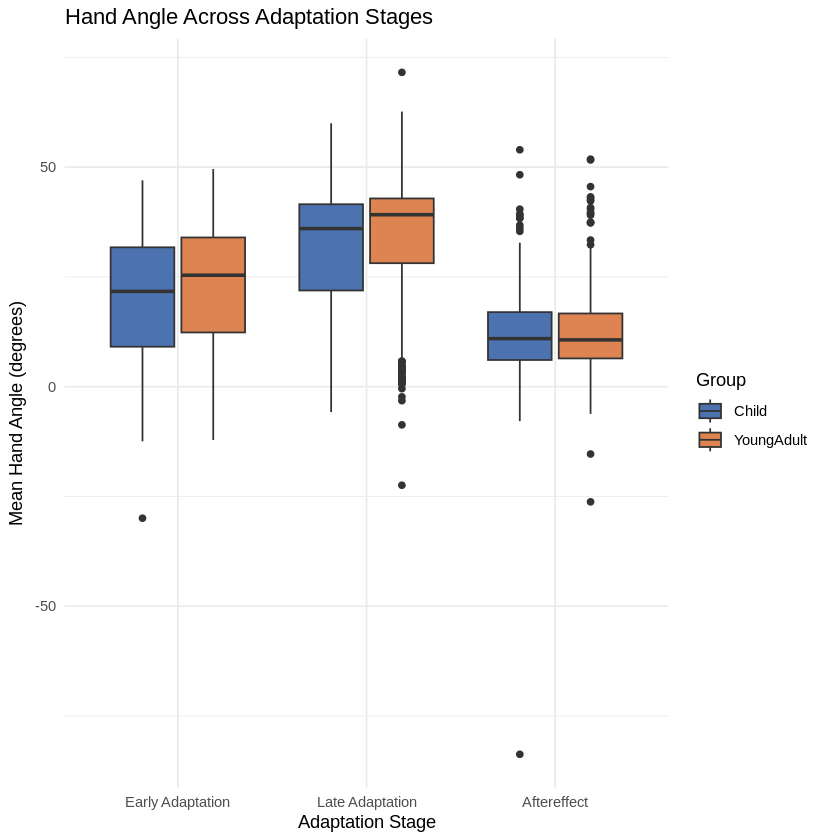

In [113]:
summary_data$Stage <- factor(summary_data$Stage,
  levels = c("Early Adaptation", "Late Adaptation", "Aftereffect")
)
ggplot(summary_data, aes(x = Stage, y = mean_angle, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = c("Child" = "#4C72B0", "YoungAdult" = "#DD8452")) +
  theme_minimal() +
  labs(
    title = "Hand Angle Across Adaptation Stages",
    x = "Adaptation Stage",
    y = "Mean Hand Angle (degrees)",
    fill = "Group"
  )

The boxplot shows that hand angle increases from early adaptation to late adaptation, indicating that participants progressively adjust their movement to compensate for rotation.

Both age groups show this pattern of increasing hand angle, suggesting successful motor adaptation across stages. Young adults appear to have slightly larger hand angles, particularly in late adaptation, though variability within groups is substantial.

Aftereffects show that both children and young adults show some retained adaptation. However, no strong group differences are shown in aftereffects, indicating similar levels of retained adaptations.

####Linear Model: Effects of Group and Stage on Hand Angle

In [114]:
model_angle <- lm(mean_angle ~ Group * Stage, data = summary_data)

summary(model_angle)


Call:
lm(formula = mean_angle ~ Group * Stage, data = summary_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-95.773  -7.172   1.348   8.346  41.906 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                           20.9046     0.5631  37.122  < 2e-16 ***
GroupYoungAdult                        2.3614     0.6781   3.482 0.000502 ***
StageLate Adaptation                  10.6620     0.7964  13.388  < 2e-16 ***
StageAftereffect                      -8.8639     0.7964 -11.130  < 2e-16 ***
GroupYoungAdult:StageLate Adaptation   0.5883     0.9590   0.613 0.539581    
GroupYoungAdult:StageAftereffect      -2.2093     0.9590  -2.304 0.021282 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.57 on 4074 degrees of freedom
Multiple R-squared:  0.3679,	Adjusted R-squared:  0.3671 
F-statistic: 474.2 on 5 and 4074 DF,  p-value: < 2.2e-16


The linear model reveals a significant effect of Stage, with hand angle increasing significantly during late adaptation (β = 10.66, p < 0.001) and decreasing during aftereffect stage (β = -8.86, p < 0.001) relative to early adaptation. This indicates that participants progressively adjust their movements over time, consistent with motor learning.

There is a significant main effect of Group (β = 2.36, p < 0.001), indicating that young adults exhibit slightly greater adaptation than children during early adaptation.

There is no significant Group × Stage interaction during late adaptation (p = 0.54), suggesting similar rates of learning across groups. However, a small but significant interaction is observed during the aftereffect stage (β = -2.21, p = 0.021), indicating slightly reduced retention in young adults compared to children.

The R^2 value is relatively high (0.368), indicating that the model explains a substantial portion of variance in hand angle, further supporting the robustness of these findings.

####Mixed-Effects Model: Trial-Level Effects on Hand Angle

In [115]:
model_angle_mixed <- lmer(HandFlip ~ Group * Stage + (1 | Subject.ID), data = clean_data)
summary(model_angle_mixed)

Linear mixed model fit by REML ['lmerMod']
Formula: HandFlip ~ Group * Stage + (1 | Subject.ID)
   Data: clean_data

REML criterion at convergence: 1289132

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-6.8339 -0.5489  0.0034  0.4945  7.2323 

Random effects:
 Groups     Name        Variance Std.Dev.
 Subject.ID (Intercept)  21.92    4.681  
 Residual               294.40   17.158  
Number of obs: 150901, groups:  Subject.ID, 1360

Fixed effects:
                                         Estimate Std. Error t value
(Intercept)                              12.12505    0.41306  29.354
GroupYoungAdult                           0.10289    0.49768   0.207
StageBaseline                           -12.13544    0.37681 -32.206
StageEarly Adaptation                     8.84811    0.44057  20.083
StageLate Adaptation                     19.49660    0.36711  53.108
StageOppositeAdaptation                 -31.67088    0.38717 -81.800
GroupYoungAdult:StageBaseline            -0.06243  

The mixed-effects model reveals a strong effect of Stage, indicating changes in hand angle across the task. During early adaptation, hand angle increases (β = 8.85), showing initial adjustments to the imposed rotations. During late adaptation, hand angle increases further (β = 19.50), showing continued learning and more complete compensation for the perturbation. During the aftereffect stage, hand angle decreases (β = -31.67), indicating a reduction in adaptation once the perturbation is removed.

Group x Stage analysis also shows significant interactions for both early adaptation (β = 2.25) and late adaptation (β = 2.85), suggesting that young adults exhibit slightly greater adaptation than children during these stages. Notably, during the aftereffect stage, a significant interaction is observed (β = -4.59), suggesting differences in how adaptation is reduced between groups after the perturbation is removed.

####Visualization: Movement Time Across Adaptation Stages

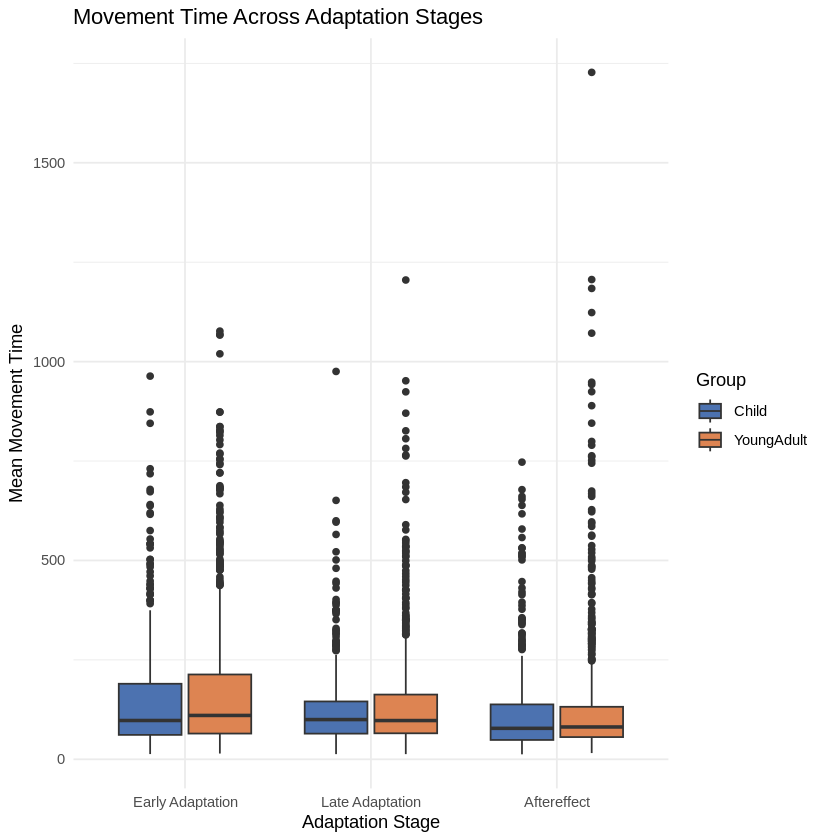

In [116]:
summary_data$Stage <- factor(summary_data$Stage,
  levels = c("Early Adaptation", "Late Adaptation", "Aftereffect")
)

ggplot(summary_data, aes(x = Stage, y = mean_MT, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = c("Child" = "#4C72B0", "YoungAdult" = "#DD8452")) +
  theme_minimal() +
  labs(
    title = "Movement Time Across Adaptation Stages",
    x = "Adaptation Stage",
    y = "Mean Movement Time",
    fill = "Group"
  )

Linear Model: Effects of Group and Stage on Movement Time

In [117]:
model_mt <- lm(mean_MT ~ Group * Stage, data = summary_data)

summary(model_mt)


Call:
lm(formula = mean_MT ~ Group * Stage, data = summary_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-159.37  -79.09  -47.16   20.05 1598.30 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                           154.747      7.021  22.039  < 2e-16 ***
GroupYoungAdult                        19.026      8.455   2.250 0.024477 *  
StageLate Adaptation                  -25.616      9.930  -2.580 0.009922 ** 
StageAftereffect                      -33.316      9.930  -3.355 0.000801 ***
GroupYoungAdult:StageLate Adaptation  -10.092     11.957  -0.844 0.398703    
GroupYoungAdult:StageAftereffect      -11.424     11.957  -0.955 0.339397    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 144.2 on 4074 degrees of freedom
Multiple R-squared:  0.01659,	Adjusted R-squared:  0.01538 
F-statistic: 13.74 on 5 and 4074 DF,  p-value: 2.471e-13


The linear model shows a significant effect of stage, with movement time highest during early adaptation (p < 0.001), indicating increased difficulty during initial learning. A small but significant effect of group is observed, while no significant Group x Stage interaction is found, suggesting that children and young adults exhibit similar patterns of performance across stages.

####Linear Model: Effects of Group and Stage on Reaction Time

In [118]:
model_rt <- lm(mean_RT ~ Group * Stage, data = summary_data)

summary(model_rt)


Call:
lm(formula = mean_RT ~ Group * Stage, data = summary_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-256.52  -66.21  -11.19   49.70  739.81 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                           296.299      4.933  60.068  < 2e-16 ***
GroupYoungAdult                        18.905      5.940   3.183  0.00147 ** 
StageLate Adaptation                  -51.532      6.976  -7.387 1.81e-13 ***
StageAftereffect                      -12.480      6.976  -1.789  0.07368 .  
GroupYoungAdult:StageLate Adaptation  -14.353      8.400  -1.709  0.08757 .  
GroupYoungAdult:StageAftereffect       -5.536      8.400  -0.659  0.50990    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 101.3 on 4074 degrees of freedom
Multiple R-squared:  0.06518,	Adjusted R-squared:  0.06403 
F-statistic: 56.81 on 5 and 4074 DF,  p-value: < 2.2e-16


Reaction time decreases significantly during late adaptation (p < 0.001), indicating improved efficiency over time. A small main effect of group is observed (p = 0.025), but no significant interaction is found, suggesting similar patterns of change across stages for both groups.


###Interpretation

These results provide partial support for the main hypotheses.



*   Young adults show significantly greater adaptation than children during early adaptation.
*   Young adults show significantly greater adaptation than children during late adaptation.
*  There is no significant group difference in the aftereffect stage.
*   Movement time and reaction time show similar patterns across groups, suggesting that observed differences in hand angle reflect differences in learning rather than overall task performance.



##Secondary Analysis

####Baseline Performance Differences

Baseline performance is examined to determine whether children and young adults differ prior to adaptation.

####Linear Models: Baseline Performance Differences Between Groups

In [119]:
lm(mean_MT ~ Group, data = baseline_data)
lm(mean_RT ~ Group, data = baseline_data)
lm(mean_ST ~ Group, data = baseline_data)


Call:
lm(formula = mean_MT ~ Group, data = baseline_data)

Coefficients:
    (Intercept)  GroupYoungAdult  
        166.050           -2.485  



Call:
lm(formula = mean_RT ~ Group, data = baseline_data)

Coefficients:
    (Intercept)  GroupYoungAdult  
         271.95            14.38  



Call:
lm(formula = mean_ST ~ Group, data = baseline_data)

Coefficients:
    (Intercept)  GroupYoungAdult  
        1653.34           -49.52  


Results indicate minimal differences between groups. Movement time is slightly lower for young adults (β = -2.49), while reaction time is slightly higher (β = 14.38). Search time shows a small decrease for young adults (β = -49.52). These differences are small in magnitude, suggesting that children and young adults do not meaningfully differ in baseline performance prior to adaptation.

####Bootstrapping: Stability of Baseline Movement Time Estimates

In [120]:
boot_fn <- function(data, index) {
  coef(lm(mean_MT ~ Group, data = data[index, ]))
}

boot_results <- boot(baseline_data, boot_fn, R = 500)
boot_results


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = baseline_data, statistic = boot_fn, R = 500)


Bootstrap Statistics :
      original      bias    std. error
t1* 166.049695 -0.04614239    5.376803
t2*  -2.484685 -0.08936091    6.492285

Bootstrapping was done to check whether the results from the original model are stable. The original model estimated baseline movement time and the difference between children and young adults using all available data.

The bootstrapped results are very similar to the original estimates, indicating that small group difference is not reliable. This supports the conclusion that children and young adults do not meaningfully differ in baseline performance.

####Logistic Regression: Predicting Group from Baseline Performance

In [121]:
baseline_data$Group <- as.factor(baseline_data$Group)

model_class <- glm(Group ~ mean_MT + mean_RT + mean_ST,
                   data = baseline_data,
                   family = "binomial")

summary(model_class)


Call:
glm(formula = Group ~ mean_MT + mean_RT + mean_ST, family = "binomial", 
    data = baseline_data)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)  1.0223153  0.3405396   3.002  0.00268 ** 
mean_MT     -0.0004692  0.0005670  -0.828  0.40794    
mean_RT      0.0043741  0.0009193   4.758 1.96e-06 ***
mean_ST     -0.0008397  0.0001932  -4.347 1.38e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1684.6  on 1359  degrees of freedom
Residual deviance: 1654.2  on 1356  degrees of freedom
AIC: 1662.2

Number of Fisher Scoring iterations: 4


A logistic regression model was used to test whether baseline behavioral measures predict group membership. Results show that reaction time (β = 0.0044, p < 0.001) and search time (β = -0.00084, p < 0.001) are significant predictors of group, while movement time is not significant(p = 0.41). However, the magnitude of these effects are small, suggesting that baseline performance measures do not strongly distinguish between children and young adults.

These results further support the conclusion that group differences in adaptation are not driven by baseline performance differences.

##Exploratory Data Analysis

Exploratory analyses examine whether behavioral and lifestyle factors predict motor adaptation. These analyses are exploratory and are not intended to test the primary hypotheses.

Participant-level behavioral variables are merged into the summary dataset to examine individual differences in adaptation.

####Data Integration: Merging Behavioral Variables into Summary Dataset

In [122]:
demo_data <- clean_data %>%
  select(Subject.ID, clumsy, videogames, Sleep, ComputerUsage) %>%
  distinct()

summary_data <- summary_data %>%
  left_join(demo_data, by = "Subject.ID")

head(summary_data)

Subject.ID,Group,Stage,mean_MT,mean_RT,mean_ST,mean_angle,clumsy,videogames,Sleep,ComputerUsage
<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>,<int>
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Aftereffect,36.33333,303.8333,2567.333,13.039709,Agree,Neutral,6,8
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Early Adaptation,112.90000,327.6000,2153.700,23.268919,Agree,Neutral,6,8
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Late Adaptation,47.56818,170.5227,1954.512,38.604005,Agree,Neutral,6,8
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Aftereffect,62.33333,296.1667,1426.833,2.495032,Disagree,Strongly Agree,6,6
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Early Adaptation,58.50000,300.8889,2014.500,39.027923,Disagree,Strongly Agree,6,6
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Late Adaptation,58.84091,217.3864,1886.318,39.834128,Disagree,Strongly Agree,6,6


####Linear Model: Behavioral Predictors of Late Adaptation

In [123]:
late_data <- summary_data %>%
  filter(Stage == "Late Adaptation")

model_explore <- lm(
  mean_angle ~ clumsy + videogames + Sleep + ComputerUsage,
  data = late_data
)

summary(model_explore)


Call:
lm(formula = mean_angle ~ clumsy + videogames + Sleep + ComputerUsage, 
    data = late_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-53.615  -7.315   4.404   8.967  38.471 

Coefficients:
                            Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 33.13028    2.27868  14.539  < 2e-16 ***
clumsyDisagree               0.26364    0.97303   0.271  0.78647    
clumsyNeutral               -1.86463    0.92172  -2.023  0.04327 *  
clumsyStrongly Agree        -0.38998    1.37278  -0.284  0.77639    
clumsyStrongly Disagree     -1.64292    1.38492  -1.186  0.23572    
videogamesDisagree          -3.01808    1.09495  -2.756  0.00592 ** 
videogamesNeutral           -2.98283    1.09713  -2.719  0.00664 ** 
videogamesStrongly Agree    -0.24130    1.11209  -0.217  0.82826    
videogamesStrongly Disagree -1.73292    1.12680  -1.538  0.12431    
Sleep                        0.42190    0.25122   1.679  0.09331 .  
ComputerUsage               -0.

A linear model is used to examine whether behavioral and lifestyle factors predict motor adaptation through hand angle measures. Analysis is centered around late adaptation to assess the complete expression of motor learning.

Results indicate that some variables, such as video game usage and clumsiness, are statistically associated with adaptation, but the effects are relatively small. Specifically, lower levels of video game usage are associated with lower hand angle, and a neutral feeling about clumsiness is associated with a negative hand angle. Sleep has a weak positive trend but is not statistically significant. Computer usage is not associated with hand angle in late adaptation.

These effects are small, and the model explains very little variance in adaptation (R² ≈ 0.018), indicating that these behavioral factors do not strongly predict motor learning.

####Visualization: Video game Usage and Late Adaptation

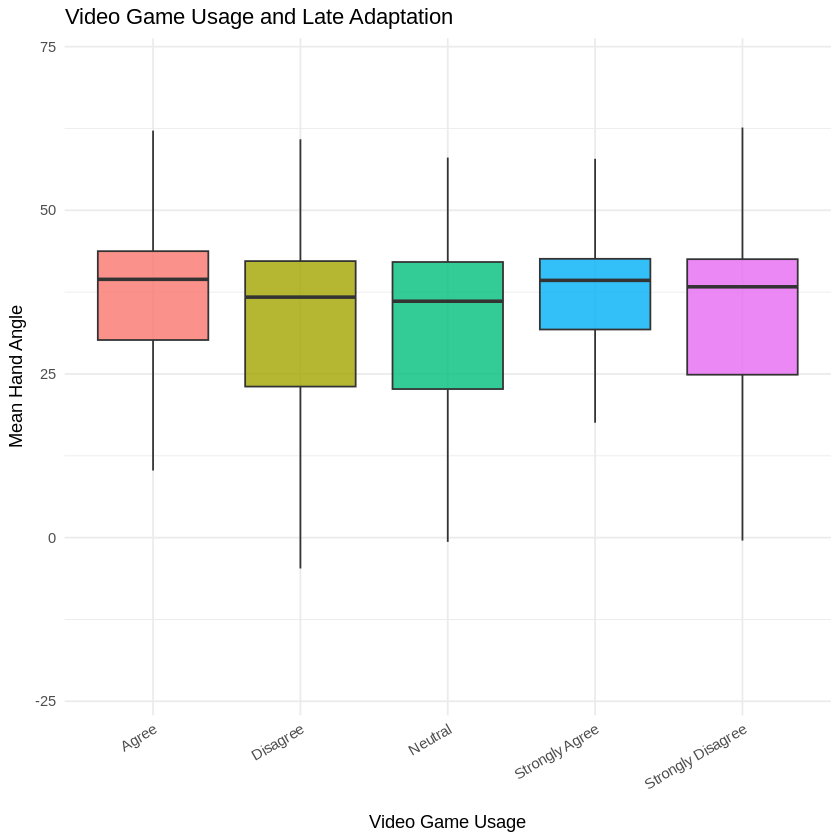

In [124]:
ggplot(late_data, aes(x = videogames, y = mean_angle, fill = videogames)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.8) +
  theme_minimal() +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 30, hjust = 1)
  ) +
  labs(
    title = "Video Game Usage and Late Adaptation",
    x = "Video Game Usage",
    y = "Mean Hand Angle"
  )

A boxplot of video game usage shows highly overlapping distributions of hand angle across all categories. Median adaptation levels are similar, and variability within each group is large, indicating no clear relationship between video game usage and motor adaptation.

####Visualization: Sleep Duration and Motor Adaptation

`geom_smooth()` using formula = 'y ~ x'


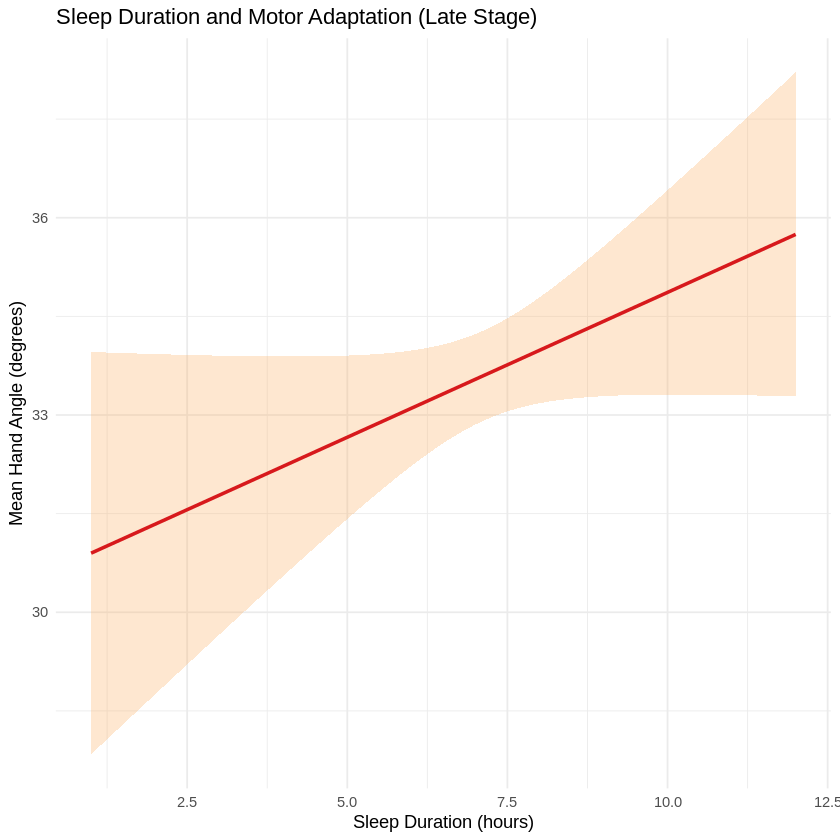

In [125]:
ggplot(late_data, aes(x = Sleep, y = mean_angle)) +
  geom_smooth(method = "lm", color = "#D7191C", fill = "#FDAE61", alpha = 0.3) +
  theme_minimal() +
  labs(
    title = "Sleep Duration and Motor Adaptation (Late Stage)",
    x = "Sleep Duration (hours)",
    y = "Mean Hand Angle (degrees)"
  )

The model suggests a weak positive relationship between sleep duration and motor adaptation. However, as shown in earlier analyses, substantial variability exists across individuals, indicating that sleep is not a strong predictor of adaptation.

####Ridge Regression: Behavioral Predictors of Motor Adaptation

[1] 6.78726

11 x 1 sparse Matrix of class "dgCMatrix"
                               s=6.78726
(Intercept)                 32.439510669
clumsyDisagree               0.548824802
clumsyNeutral               -1.053833296
clumsyStrongly Agree         0.007799909
clumsyStrongly Disagree     -0.822705827
videogamesDisagree          -1.343251605
videogamesNeutral           -1.358863126
videogamesStrongly Agree     0.538340512
videogamesStrongly Disagree -0.435449853
Sleep                        0.284877043
ComputerUsage               -0.014106956

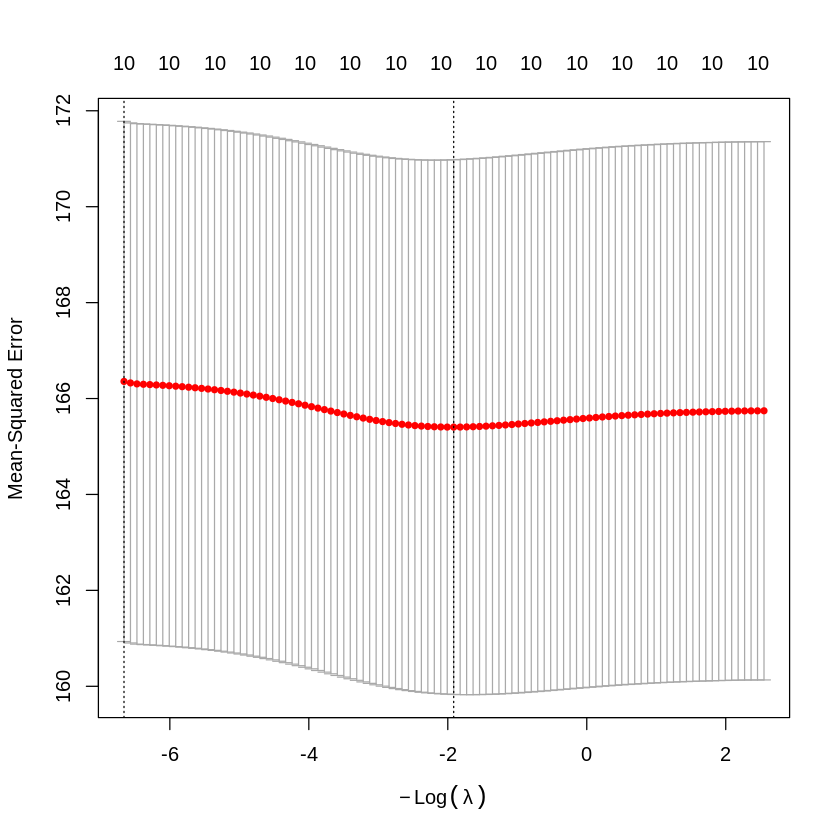

In [126]:
ridge_data <- late_data %>%
  select(mean_angle, clumsy, videogames, Sleep, ComputerUsage) %>%
  drop_na()

x <- model.matrix(mean_angle ~ clumsy + videogames + Sleep + ComputerUsage, ridge_data)[,-1]
y <- ridge_data$mean_angle

cv.out <- cv.glmnet(x, y, alpha = 0)
plot(cv.out)

bestlam <- cv.out$lambda.min
bestlam

ridge.mod <- glmnet(x, y, alpha = 0)
coef(ridge.mod, s = bestlam)

Ridge regression is used to evaluate the predictive contribution of behavioral variables. Cross-validation identifies a best tuning parameter, but the error curve is relatively flat, indicating that there is limited improvement in prediction across models. The resulting coefficients are small, suggesting that behavioral variables have weak effects on motor adaptation.

Across all analyses, results consistently show that motor adaptation differs between groups during learning, while baseline performance and behavioral factors do not strongly explain these differences.

#Conclusion

This project aimed to examine how motor adaptation differs between children and young adults using a visuomotor rotation task. Results showed a strong effect of adaptation stage, with participants increasing their hand angle over time and demonstrating partial retention during the aftereffect phase. These findings are consistent with the process of motor learning, in which individuals gradually adjust their movements in response to error.

While young adults demonstrated slightly greater adaptation overall, group differences were relatively small when compared to the effect of learning stage. Additionally, movement time and reaction time showed similar patterns across groups, suggesting that differences in hand angle across groups reflect differences in learning rather than general performance on the task.

Secondary analyses reveal that baseline performance was largely similar between groups, and exploratory analyses showed that behavioral factors such as video game use and sleep were only weakly tied to adaptation. Across multiple methods, these variables explained little variance in motor learning.

Overall, these results suggest that motor adaptation is primarily driven by the stage of learning. These findings contribute to our understanding of how motor learning develops and highlights the importance of separating learning processes from general performance measures. Future work may further examine how implicit and explicit learning processes contribute to these developmental differences.